# How has GenAI impacted ICT Job Postings?

## 1. ICT Professionals Vacancies Over Time (Australia)

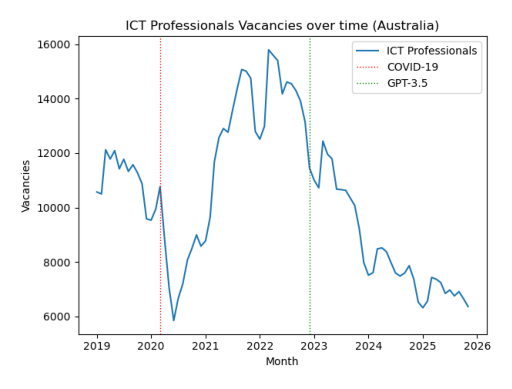

In [57]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "../Vacancy_Trends/outputs/images/ICT Professionals.png" 
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

There is obviously a decline in the number of job postings in ICT since GenAI started to become mainstream (Nov 2022, Release of GPT 3.5).

**But is GenAI the (sole) cause of the decline?**

To answer this, we need to compare the change in job postings of ICT to other professions.

## Calculating percentage change across all sectors after GPT 3.5 Release

In [94]:
import pandas as pd

# Load the  vacancy data from CSV
df = pd.read_csv('../Vacancy_Trends/outputs/dataframes/aus_vacancy.csv')
df = df.drop("Unnamed: 0", axis=1)

# Identify columns representing dates (formatted as 'Month-Year')
date_cols = [col for col in df.columns if '-' in col]

df.head(5)

,ANZSCO_TITLE,ANZSCO_CODE,Jan-19,Feb-19,Mar-19,Apr-19,May-19,Jun-19,Jul-19,Aug-19,...,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25
0,TOTAL,0,165363,165429,185974,174667,176608,169588,177768,175656,...,192841,215338,204042,206099,201701,210416,208051,214332,215499,209716
1,MANAGERS,1,21384,21744,24286,22888,22780,21810,22467,22145,...,23260,26155,24934,25301,24725,25513,25059,25396,25140,23969
2,"Chief Executives, Managing Directors & Legisla...",11,738,733,807,804,845,811,840,803,...,956,1021,1011,1051,1047,1080,1053,1044,1040,1005
3,Farmers and Farm Managers,12,109,122,149,132,127,123,136,142,...,173,193,187,197,187,199,198,200,190,178
4,"Hospitality, Retail and Service Managers",14,5142,5273,5841,5344,5223,4974,5070,5149,...,7159,8012,7456,7548,7365,7613,7531,7626,7582,7097


In [95]:
# Calculating percentage change compared to Nov-2022 (GPT 3.5 Release)

latest_month = date_cols[-1]
df['percent_change'] = ((df[latest_month] - df['Nov-22']) / df['Nov-22']) * 100

## 2. Visualization

### Percentage Chagne in Job Postings after GPT 3.5 Release

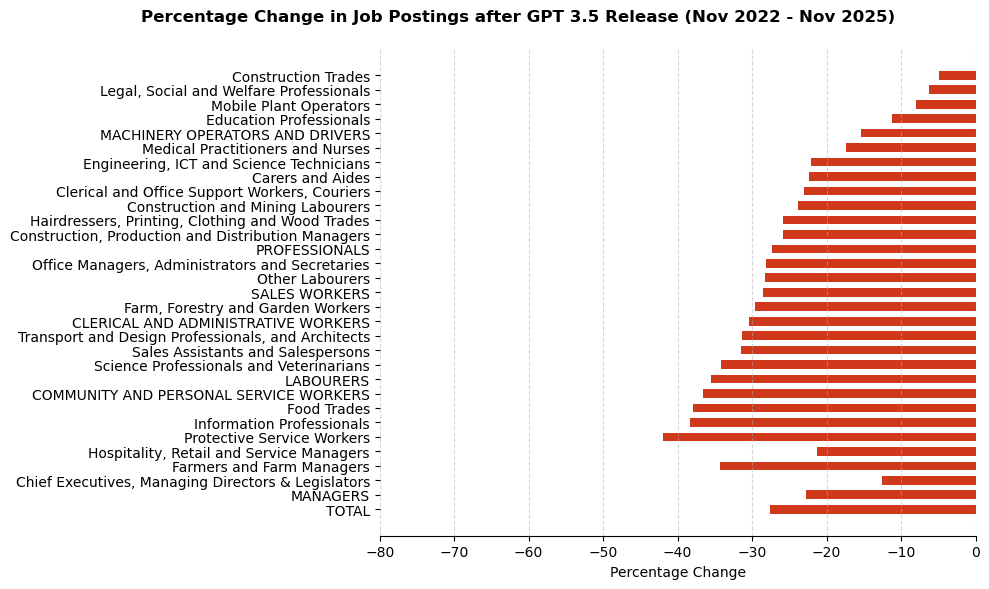

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Separate and sort data
code_0 = df[df['ANZSCO_CODE'] == "0"]
top5 = df[:5]
others = df[df['ANZSCO_CODE'] != "0"][5::2].sort_values('percent_change', ascending=True)
df_plot = pd.concat([top5, others, code_0])

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['ANZSCO_TITLE'], df_plot['percent_change'], color='#CF381B', height=0.6)

# Style
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(-80, 0)
    
plt.title('Percentage Change in Job Postings after GPT 3.5 Release (Nov 2022 - Nov 2025)', loc='left', fontweight='bold', pad=20, x=-0.4)
plt.xlabel('Percentage Change')
plt.tight_layout()

plt.savefig("outputs/images/ai_impact_on_job_postings")
plt.show()

### Cash Rate Target (Interest Rate) Change

In [91]:
# Data cleaning
df2 = pd.read_csv('data/a02hist.csv')
df2 = df2[84:105]
df2.rename(columns={'A2 RESERVE BANK OF AUSTRALIA – CHANGES IN MONETARY POLICY AND ADMINISTERED RATES': "Date", 'Unnamed: 2': "Cash Rate Target"}, inplace=True)
df2 = df2[['Date', 'Cash Rate Target']]

df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%b-%Y', errors='coerce')
df2['Cash Rate Target'] = pd.to_numeric(df2['Cash Rate Target'], errors='coerce')
df2 = df2.dropna()  # Remove any invalid rows

In [92]:
import textwrap

def plot_vacancy_trends(aus_df, df2, code, code_alt=None, save=False):
    title = aus_df.loc[aus_df["ANZSCO_CODE"] == code, "ANZSCO_TITLE"].item()
    full_title = title
    vline_covid = pd.to_datetime("2020-3-01")
    vline_gpt = pd.to_datetime("2022-11-30")
    
    months = [c for c in aus_df.columns if "-" in c]
    months_dt = pd.to_datetime(months, format="%b-%y")
    values = aus_df.loc[aus_df["ANZSCO_CODE"] == code, months].iloc[0].tolist()
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot vacancy data on primary axis
    color1 = 'tab:blue'
    ax1.plot(months_dt, values, label=title, color=color1, linewidth=2)
    ax1.set_xlabel("Month", fontsize=12)
    ax1.set_ylabel("Vacancies", color=color1, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    if code_alt:
        title_alt = aus_df.loc[aus_df["ANZSCO_CODE"] == code_alt, "ANZSCO_TITLE"].item()
        full_title = f"{title} vs {title_alt}"
        values_alt = aus_df.loc[aus_df["ANZSCO_CODE"] == code_alt, months].iloc[0].tolist()
        ax1.plot(months_dt, values_alt, color="brown", label=title_alt, linewidth=2)
    
    # Create secondary axis for cash rate
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.plot(df2["Date"], df2['Cash Rate Target'], color=color2, 
             label='Cash Rate Target', linewidth=2, linestyle='--')
    ax2.set_ylabel("Cash Rate Target (%)", color=color2, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Set y-axis limits for better visibility (adjust these as needed)
    # ax2.set_ylim([0, df2['Cash Rate Target'].max() * 1.1])
    
    # Add vertical lines
    ax1.axvline(vline_covid, linestyle=":", linewidth=1.5, label="COVID-19", color="gray", alpha=0.7)
    ax1.axvline(vline_gpt, linestyle=":", linewidth=1.5, label="GPT-3.5", color="green", alpha=0.7)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    # Wrap the title if too long
    wrapped_title = "\n".join(
        textwrap.wrap(f"{full_title} Vacancies vs Cash Rate Target (Australia)", width=50)
    )
    ax1.set_title(wrapped_title, fontsize=14)
    
    # Add grid for better readability
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f'outputs/images/ict_vacancy_vs_crt.png', dpi=300, bbox_inches='tight') 
    plt.show()
    
    # Print some debug info
    print(f"Vacancies range: {min(values):.0f} to {max(values):.0f}")
    print(f"Cash Rate range: {df2['Cash Rate Target'].min():.2f}% to {df2['Cash Rate Target'].max():.2f}%")

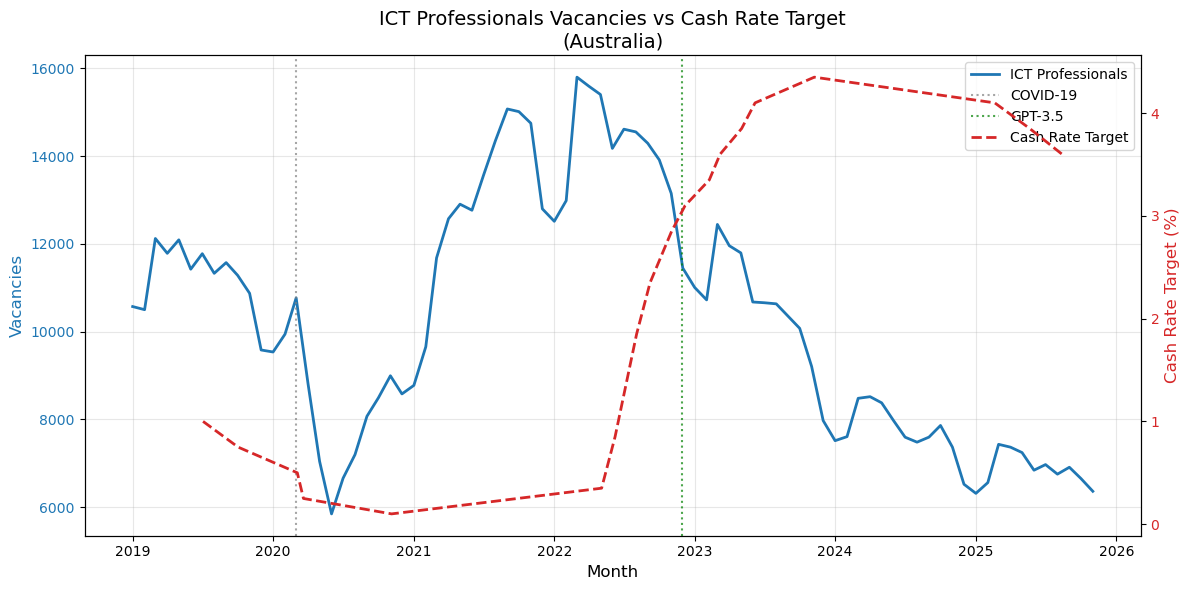

Vacancies range: 5844 to 15801
Cash Rate range: 0.10% to 4.35%


In [93]:
plot_vacancy_trends(df, df2, "26", save=True)